# Configuration

Use the following configuration
> dataquest conda enviroment

> pip install streamlit

In [ ]:
%pip install streamlit==1.29.0

# 1) Introduction

In previous lessons, we saw how to use Streamlit to build apps using widgets and layout elements. However, there's been a significant limitation with our work so far: Streamlit reruns the entire app whenever a user interacts with it. **This can lead to losing user inputs and states**, which isn't ideal for applications requiring persistent user sessions.

In this lesson, we'll address this by learning how to manage user inputs with session state. The state of a web application refers to the retention of user choices and inputs, acting as its "memory".

To help understand this, let's consider a simple analogy: if you're reading a book and use a bookmark to keep your place, you can remember where you left off. You can continue from the same spot without starting over when you return. Streamlit's session state has a similar capability, allowing your application to "remember" user-input data in forms or when navigating between different app sections.

We'll continue working with the GlobalJava Roasters application that we began to develop in previous lessons. In this lesson, we'll create a **'Chat With Us!'** page where users can interact with a simple chatbot without losing the context of their conversation. We'll leverage the session state to manage these dynamic elements effectively.

In this lesson, you'll learn to:

1. Understand and implement Streamlit's state in applications.

1. Manage user inputs and responses using session state.

1. Integrate interactive chat inputs.

1. Test and confirm the effectiveness of state management.

# 2) Setting Up Session State

To begin working with session state, we must first understand how to initialize and use **session state variables**. These variables are like placeholders, holding data between user interactions and app reruns. They are particularly useful for sustaining user choices or preserving ongoing processes in an application.

Streamlit handles state management through the `st.session_state` [function](https://docs.streamlit.io/develop/api-reference/caching-and-state/st.session_state), which operates like a Python dictionary. In this dictionary-like structure, each **key** represents a session state variable name, and its **value** is the data itself. We can take a look at this structure from a Streamlit app once we define the variable by using st.session_state:

```python
st.session_state['key'] = 'value'

# Display the current session state
st.session_state
```

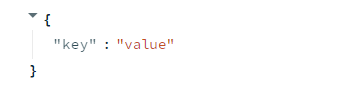

If we try to use a session state variable before it's been "defined," we'll get an error:

```python
st.write(st.session_state['test_variable'])

KeyError: 'st.session_state has no key "test_variable". Did you forget to initialize it? More info: https://docs.streamlit.io/library/advanced-features/session-state#initialization'
```

## Initializing Session State Variables
You need to initialize the state variable with an if block because Streamlit re-runs the script from top to bottom on every interaction.

**Why Use an `if` Block?**

If you simply did:

```st.session_state['chat_active'] = False```

This would be re-executed on every interaction, resetting the value of chat_active to False every time.

**The Correct Approach**

By using the if block:

```python
if 'chat_active' not in st.session_state:
    st.session_state['chat_active'] = False
```

You're checking if the `chat_active` variable already exists in `st.session_state`. If it doesn't exist (i.e., it's the first time the script is run), you initialize it with False. If it already exists, you do nothing and the current value is preserved.

This ensures that the variable is initialized only once and retains its value between interactions.

Here, we initialize a `test_variable` variable in the session state, set to None initially. It can later be updated to reflect the user's actual response.

```python
if 'test_variable' not in st.session_state:
    st.session_state['test_variable'] = None
```

Let's see an example that counts the number of times the script has been rerun manually:

```python
if 'rerun_count' not in st.session_state:
    st.session_state['rerun_count'] = 0
st.session_state['rerun_count'] += 1

st.write(f"This script has been rerun {st.session_state['rerun_count']} times.")
```

Additionally, it's worth noting that session state variables are cleared at the end of a session, typically when the user closes the browser or the app is restarted. This behavior is important for protecting user privacy and ensuring that sensitive information isn't retained beyond the interaction. It's essential to design your app with this in mind, particularly when handling personal data or other sensitive information.

## Instructions

You will now practice setting up a session state variable for the **"Chat with us!"** page we're developing for the GlobalJava Roasters website. This variable will help us track whether a user has begun interacting with the chat.

1. Use conditional logic to check whether a session state variable named chat_active exists. If not, initialize it with the value False.

1. Create a second conditional block that checks if the chat is active (chat_active == True). If the chat is not active, display the following welcome message inviting the user to start the chat:

    * "Welcome to GlobalJava Roasters!"

In [ ]:
import streamlit as st
if "chat_active" not in st.session_state:
    st.session_state['chat_active']= False
    
if st.session_state['chat_active'] == True:
    pass
else:
    st.write("Welcome to GlobalJava Roasters!")

# 3) Manipulating Session State with Widgets

Having initialized session state variables, let's explore how to interact with these variables using widgets. As we've seen in previous lessons, widgets like **buttons**, **sliders**, and **text** inputs enable user interactions within the app. With the session state, we can allow these interactions to make persistent changes to the app's interface and behavior.

For example, the `st.button` widget can respond to a user's clicks by changing the application's state. To illustrate, we can modify the `rerun_count` script from the previous screen to increment in response to button clicks instead of manual reruns.

When clicked, this button will update the rerun_count variable in the session state. This example demonstrates how user actions can influence the app's state and showcases the immediate visibility of these changes.

```python
if 'rerun_count' not in st.session_state:
    st.session_state['rerun_count'] = 0

if st.button('Increase Count'):
    st.session_state['rerun_count'] += 1

st.write(f"The button has been clicked {st.session_state['rerun_count']} times.")
```

**Storing User Input**

Streamlit can also store user input data like `st.text_input` in a session state variable. Let's use text input to determine the way an app responds:

```python
if 'username' not in st.session_state:
    st.session_state['username'] = ''

username = st.text_input("Username", st.session_state['username'])

if st.button("Submit"):
    st.session_state['username'] = username
    if st.session_state['username'] == "Surprise":
        st.balloons()
        st.write("You found me!")
    elif st.session_state['username']:
        st.write(f"Welcome, {st.session_state['username']}!")
    else:
        st.write("Please enter a username.")
```

Here, whatever the user types into the text input is saved into the variable username in the session state only when the button is clicked. Then, the app responds dynamically to this stored data depending on what the username is. For example, if users type "Surprise," they will see a special balloon animation.

It's worth noting the significance of the "Submit" button in this interaction. By storing the username in the session state after the button click rather than with every keystroke, we reduce unnecessary reruns of the app. This makes the app more efficient and ensures that the session state is only updated with intentional user actions, not accidental keystrokes.

To sum it up, Streamlit widgets are key components for manipulating the session state, allowing real-time responses to user inputs and enhancing the interactivity of applications. Changes to session state variables persist across reruns, maintaining the continuity of user interactions.

Understanding and leveraging these widget interactions will be particularly important for the GlobalJava Roaster chatbot we'll build in the rest of this lesson. As users engage with the chatbot, their input will be stored in the session state, allowing it to maintain context and provide relevant responses, creating a dynamic and engaging user experience.

## Instructions

In this exercise, you will integrate Streamlit widgets to interact with session state variables for a chat feature. You will create a user name input and a button to activate a chat session and display personalized messages.

1. Initialize two session state variables: `chat_active` and `user_name`. Set `chat_active` to **False** and `user_name` to an **empty string** at the beginning of your script.

1. Create a text input widget for the user to enter their name. The value of this input should default to the **current value of the user_name** session state variable.

1. Implement a button labeled 'Begin Chat'. When this button is clicked, check if the user has entered a name. If a name is entered, set chat_active to True and update user_name in the session state with the entered name.

1. Construct a conditional statement to display a personalized welcome message if chat_active is True and user_name is not an empty string. This message should greet the user by name and inform them that they are now chatting with GlobalJava Roasters.

1. Include an additional condition to prompt the user to enter their name if chat_active is True but no name has been entered.


In [ ]:
import streamlit as st

if 'chat_active' not in st.session_state:
    st.session_state['chat_active'] = False
if 'user_name' not in st.session_state:
    st.session_state['user_name'] = ''

user_input = st.text_input('Enter your name:', value=st.session_state['user_name'])

if st.button('Begin Chat'):
    if user_input:
        st.session_state['chat_active'] = True
        st.session_state['user_name'] = user_input

if st.session_state['chat_active'] and st.session_state['user_name']:
    st.write(f"Hello {st.session_state['user_name']}, welcome to our chat service!")
    st.write("You are now chatting with GlobalJava Roasters.")
else:
    if st.session_state['chat_active']:
        st.write("Please enter your name to begin the chat.")

# 4) Integrating st.chat_message for Dynamic Interactions

Now that we understand the basics of managing session state in Streamlit, we can get to the heart of our GlobalJava Roaster's chat page: **the chat elements!**


Streamlit's `st.chat_message` [function](https://docs.streamlit.io/develop/api-reference/chat/st.chat_message) is specifically designed for these dynamic interactions, displaying messages in a chat format that is familiar to users and enhances the conversational user experience.

`st.chat_message` inserts a chat message container (similar to the message containers you may be familiar with from other instant messaging tools such as Slack or sending SMS text messages on a SmartPhone). It takes one required parameter: the name of the message author (such as "Chatbot" or "User"). There is also an optional "avatar" parameter that lets us set a custom emoji to display next to each message. Here's the general syntax:

```python
 st.chat_message(name, avatar=None) 
 ```

If we leave the "avatar" parameter empty, Streamlit will use default icons when the `name` parameter matches specific keywords such as "user," "assistant," "ai," or "human."

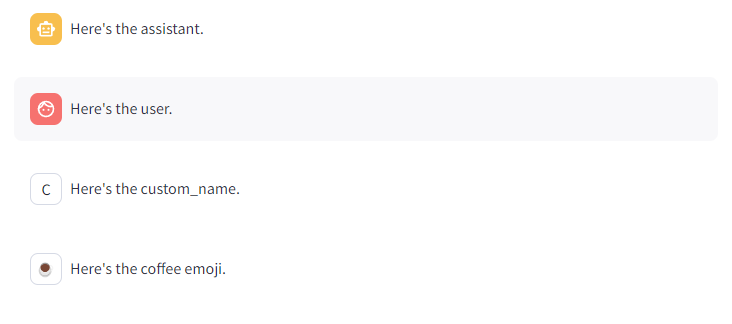

## Basic Usage of `st.chat_message`

Let's start by exploring how to use `st.chat_message` to display simple messages:

```python
with st.chat_message("assistant"):
    st.write("Welcome to our support chat!")

with st.chat_message("user"):
    st.write("Hi, I have a question about my order.")
```

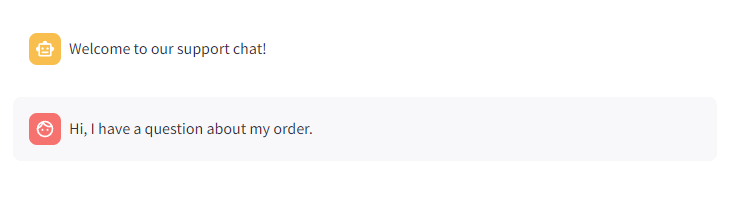


The example above shows how messages from different participants in the chat - like a chatbot assistant or a user - can be distinguished using `st.chat_message`. We can also see that each distinct chat message is contained in its own 'with' block, which is the preferred way to implement the chat message element.

## Customizing Messages

We can also customize messages to include more than just text. For example, we might want to add links, lists, or even images within a chat message:

```python
with st.chat_message("assistant"):
    st.write("For detailed information, visit our [Return Policy](https://www.example.com/return-policy) page.")
    st.image("coffee.jpg")
```

This customization adds depth to our chat interface, making it more informative and user-friendly.

While the `st.chat_message` element forms the backbone of our chat app, we still don't know how to display user-generated input. We'll cover this on the next screen, but let's practice setting up a chat message for our app for now.


## Instructions

In this exercise, you'll create a basic chat interaction on the **'Chat with us!'** page of the GlobalJava Roasters app. Use `st.chat_message` to simulate a single exchange between the user and the chatbot. The chatbot will respond to a predefined user message with a preset response.

Display a simulated chatbot message welcoming the user ("Welcome to the chat!").
Add a user question ("What are your store hours?").

In [ ]:
import streamlit as st

with st.chat_message("chatbot"):
    st.write("Welcome to the the chat!")
    
with st.chat_message("user"):
    st.write("What are your store hours?")

# 5) Creating Interactive Chat with st.chat_input

On the previous screen, we used `st.chat_message` to display messages in Streamlit, but we now need to learn about `st.chat_input` to enable user interaction. This widget allows users to type their own messages, providing a conversational interface with the application.

## Engaging Users with `st.chat_input`

The `st.chat_input` [function](https://docs.streamlit.io/develop/api-reference/chat/st.chat_input) captures user input within a chat interface. It works similarly to the standard st.text_input element but is styled specifically for chat applications. Here is a basic example:

> `user_input = st.chat_input("Send a message")`

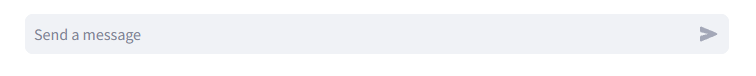


In this example, when a user types a message and submits it by clicking the arrow or pressing "Enter," the value they entered is stored in the `user_input` variable. This value can then be used within the application to display the message back to the user or to process it further:

```python
user_message = st.chat_input("Type your message here")

with st.chat_message("chatbot"):
    st.write("Hello! How can I assist you today?")

with st.chat_message("user"):
    user_message
```

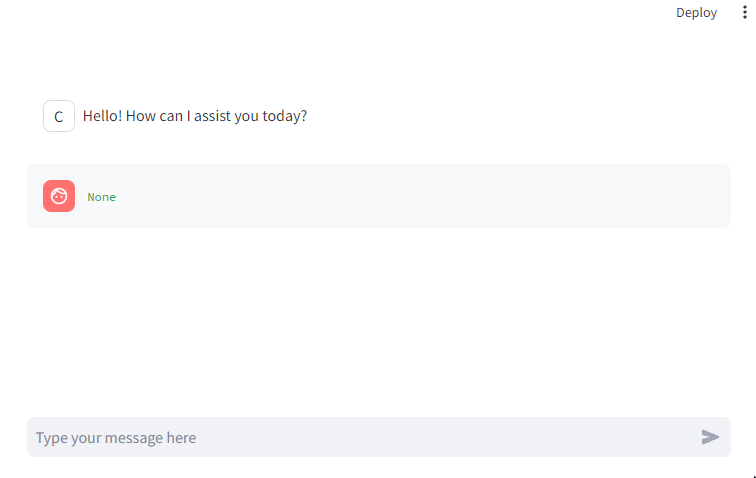

The snippet above shows that our code does not retain the chat history; it shows only the most recent user input. This is because we haven't told our Streamlit app to preserve each message in the session state. Instead, it overwrites each message every time the app reruns. Let's see how we can address this by adding a **chat history**.

## Integrating Chat History

A key aspect of interactive chats is maintaining a history of the conversation. We can use Streamlit's session state to store this chat history. For instance, if we want to append user messages to a list that represents the chat history, we could do the following:

```python
user_input = st.chat_input("Send a message")
if 'chat_history' not in st.session_state:
    st.session_state['chat_history'] = []

if user_input:
    st.session_state['chat_history'].append(user_input)

st.session_state
```

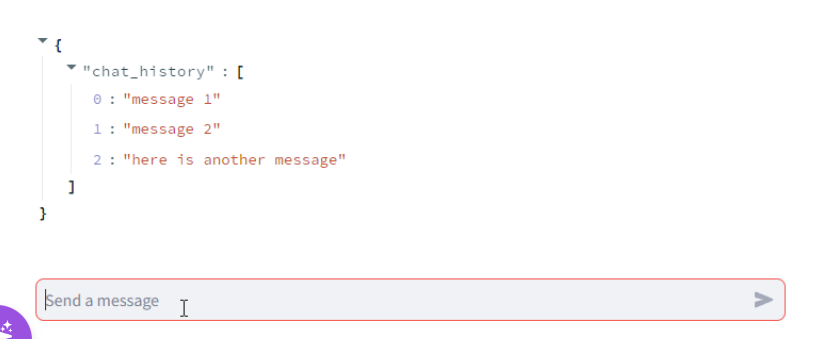

First, we initialize a session state variable called `chat_history` as an **empty list**, and then we use Python's built-in `append()` method to add each user input to the list. Finally, displaying `st.session_state` confirms that user inputs are being stored as intended.

Maintaining a chat history allows users to see the entire conversation, creating a more cohesive and engaging user experience.

## Displaying Chat History

To convert our raw session state variable into a more visually appealing chat format, we can display past messages by iterating over the chat history list with a **for loop**:

```python
for message in st.session_state['chat_history']:
    # Use st.chat_message to display each message
    with st.chat_message("user"):
        st.write(message)
```

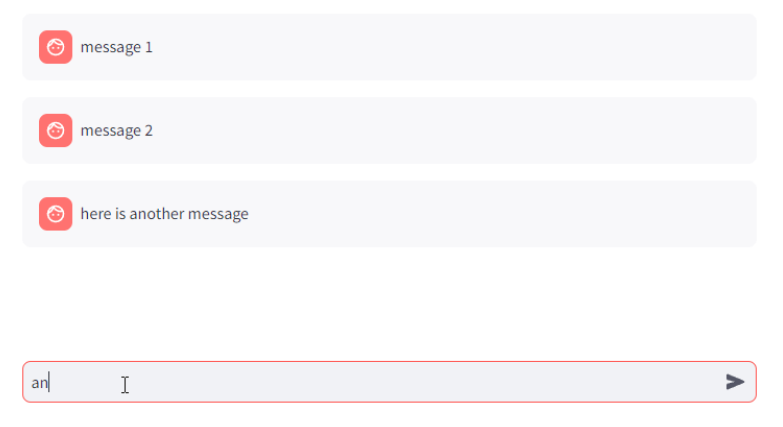

This loop displays each user message from the chat history using the `st.chat_message` widget. On the next screen, we'll differentiate between user and chatbot messages to create a complete conversation log.

**Note:** In the current version of Streamlit, st.chat_input can only be implemented once per app page and inside the main area of the app. **It can't** be used in sidebars, columns, expanders, or tabs.

## Instructions

In this exercise, you will enhance the 'Chat with us!' page of the GlobalJava Roasters app by adding `st.chat_input` for user interactions and using the session state to manage the chat history. The goal is to allow users to type messages and see a conversation log.

1. Add `st.chat_input` to the page to enable users to send messages. Store the user input in a variable named `user_message`.

1. Initialize a session state variable named `chat_history` as an empty list.

1. If `user_message` is not **None**, append it to `chat_history`.

1. Iterate over `chat_history` and use `st.chat_message` to display each message as a user message.

1. Ensure the chat history is displayed every time the page reruns, preserving the conversation.

In [ ]:
import streamlit as st

with st.chat_message("chatbot"):
    st.write("Welcome to the chat!")

user_input = st.chat_input("Write a message.")

if 'chat_history' not in st.session_state:
    st.session_state['chat_history'] = []
    
if user_input:
    st.session_state['chat_history'].append(user_input)
    
for message in st.session_state['chat_history']:
    with st.chat_message("user"):
        st.write(message)

# 6) Managing Chat State for a Cohesive Experience

We now have all the pieces in place to get our chatbot to have a conversation, so let's enhance the chat interface by incorporating both **user inputs and chatbot** responses in a format that clearly distinguishes between the two.

## Structuring Chat History with Sender Information

Previously, we stored chat messages in our session state as items in a list. To create a more interactive and realistic chat experience, we'll modify this approach by storing each message as a **dictionary** within our `chat_history`. This dictionary includes two items:

1. A "sender" key, with a value indicating whether the message is from the *user* or the *bot*.

1. A "message" key, with a value that contains the *message* contents.

Here, we can compare the old list item method:

> `st.session_state['chat_history'].append(user_input)`

And the new dictionary method:

> `st.session_state['chat_history'].append({"sender": "user", "message": user_input})` 

Here, the code is similar to what we've been working with already, but we can see that there are two `append` methods now:

1. one that adds the user input as a dictionary to the `chat_history`

1. another that adds the "bot" replies as a dictionary. Here's what the output looks like if we take a peek at the `st.session_state`:

## Displaying a Structured Conversation

With the chat history now containing dictionaries with sender information, we can iterate over these entries to display a structured and coherent conversation:

```python
for chat in st.session_state['chat_history']:
    with st.chat_message(chat["sender"]):
        st.write(chat["message"])
```

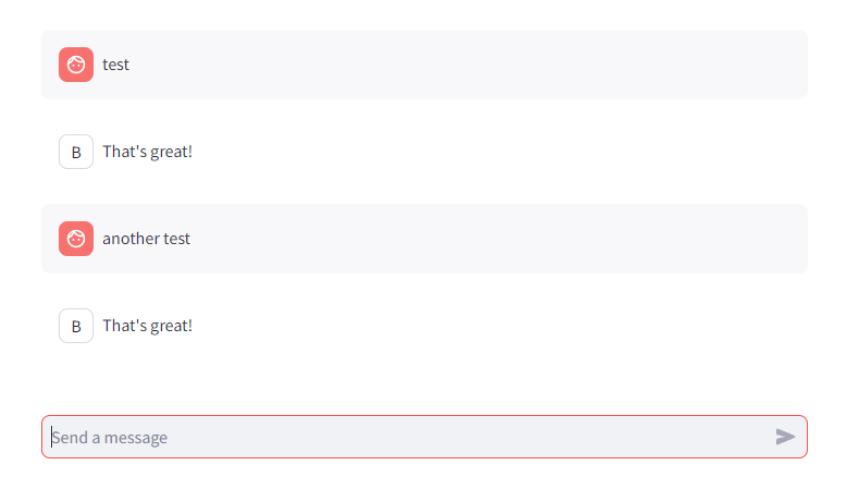

This structured approach provides a seamless and engaging user experience, keeping the conversation's context and flow intact.

## Instructions

GlobalJava Roasters wants the "Chat with Us!" page to have a random collection of chatbot replies instead of displaying one message over and over again. We've imported the random module and provided a list of bot_responses in the code editor to get you started.

1. In the i`f user_input` block:
    
    * Append the user's latest `user_input` message to `chat_history` as a dictionary, with a "sender" key set to **"user"** and a "message" key set to the `user_input`.

    * Using `random.choice`, generate a random bot response and append it to `chat_history`. There should be a "sender" key set to "chatbot" and a "message" key set to the randomly generated message.

1. In the `for` loop, display each structured message from `chat_history` in the chat interface using `st.chat_message`.

In [ ]:
import streamlit as st
import random

bot_responses = [
    "Sure, let me check that for you.",
    "I'm not quite sure. Let me find out.",
    "Hmm, I need to think about that.",
    "Interesting question! Give me a moment."
]

user_input = st.chat_input("Write a message.")

if 'chat_history' not in st.session_state:
    st.session_state['chat_history'] = []
    
if user_input:
    # capture and store user and chatbot messages
    st.session_state['chat_history'].append({"sender": "user", "message": user_input})
    #random resonse
    
    bot_response = random.choice(bot_responses)
    st.session_state['chat_history'].append({"sender": "chatbot", "message": bot_response})
        
           
    
for message in st.session_state['chat_history']:
    # display user and chatbot messages
    with st.chat_message(message["sender"]):
        st.write(message['message'])

# 7) Converting Chat State to a Class

Having developed a functional chat interface with user and bot interactions, we're now ready to improve our chatbot's architecture. This step involves transitioning from a procedural code style to a more robust **class-based approach**. By encapsulating our chat logic within a class, we can enhance our chat application's organization, maintainability, and scalability.


## Why Use a Class for Chat Management?

Classes in Python offer a way to bundle data and functionality together. Creating a chat management class will allow us to:

1. **Encapsulate Chat Logic**: Group related properties (like chat history) and methods (like adding messages or generating responses) within a cohesive unit.

1. **Improve Readability and Maintenance:** Make our code more readable and easier to maintain, especially as the complexity of our chatbot increases.

1. **Facilitate Code Reusability**: Easily reuse and extend the chat logic in other parts of our application or future projects.

## Designing Our ChatManager Class

We'll design a ChatManager class that encapsulates all the functionalities related to managing a chat session. This class will handle storing chat history, adding new messages, and potentially integrating with AI models for generating responses.

Here's a basic structure for our `ChatManager` class:

```python
class ChatManager:
    def __init__(self):
        self.chat_history = []

    def add_message(self, sender, message):
        self.chat_history.append({"sender": sender, "message": message})

    def get_chat_history(self):
        return self.chat_history
```

This `ChatManager` class does three things:

1. Initializes an **empty** `chat_history` list as an attribute.

1. Creates an `add_message` method that adds message information to the `chat_history`.

1. Creates a `get_chat_history` method to retrieve `chat_history`.

If we want to create additional functionality for our chatbot, we can easily add new attributes or methods to the `ChatManager` class to help keep our code neat and organized. For example, we could create a `chat_history_length` attribute that counts how many messages are in the `chat_history` and then use it in a `limit_chat_history` method to keep only the most recent 20 messages of a chat.

## Integrating ChatManager with Streamlit

We can now refactor (modify) our Streamlit app to use the `ChatManager` class using the following steps:

1. `Initialize ChatManager`: Create an instance of `ChatManager` in our Streamlit app. This ensures that the instance of ChatManager that we want to use remains across all reruns of the app (otherwise, the chat history would reset).

1. `Collect User Input`: Use `st.chat_input` to capture user input and pass it to our ChatManager.

1. Handle User Input: Use the `add_message` method to add user and bot messages to the chat history.

1. Display Chat History: Iterate over `get_chat_history` to display the conversation using `st.chat_message`.

Example:

```python
# Initialize ChatManager
if 'chat_manager' not in st.session_state:
    st.session_state['chat_manager'] = ChatManager()

chat_manager = st.session_state['chat_manager']

# Collect and Handle user input
user_input = st.chat_input("Send a message")
if user_input:
    chat_manager.add_message("user", user_input)
    bot_response = "That's great!"
    chat_manager.add_message("bot", bot_response)

# Display chat history
for chat in chat_manager.get_chat_history():
    with st.chat_message(chat["sender"]):
        st.write(chat["message"])
```

## Instructions

GlobalJava Roasters has made great strides with its "Chat with Us!" feature. Let's upgrade the chat functionality by refactoring the chat code with a dedicated class. This will make our code cleaner and more maintainable. Follow these steps to integrate the ChatManager class:

1. **Create the ChatManager Class**:

* Define a `ChatManager` class with an `__init__` method that initializes an empty list called `chat_history`.

* Add an `add_message` method to the class that takes sender and message as parameters and appends them as a dictionary to chat_history.

* Add a `get_chat_history` method that returns the chat_history list.

1. **Refactor the Streamlit App**:

* Initialize an instance of ChatManager in `st.session_state` if it doesn't already exist.

* Collect user input using st.chat_input.

* In the if `user_input` block, use the `add_message` method to add user input and a random bot response to the chat history.

* Iterate over the chat history using the get_chat_history method and display each message using st.chat_message.

In [ ]:
import streamlit as st
import random

bot_responses = [
        "Sure, let me check that for you.",
        "I'm not quite sure. Let me find out.",
        "Hmm, I need to think about that.",
        "Interesting question! Give me a moment."
    ]

# Define and initialize your ChatManager class here:
class ChatManager:
    def __init__(self):
        self.chat_history = []

    def add_message(self, sender, message):
        self.chat_history.append({"sender": sender, "message": message})

    def get_chat_history(self):
        return self.chat_history

# Initialize ChatManager
if 'chat_manager' not in st.session_state:
    st.session_state['chat_manager'] = ChatManager()

chat_manager = st.session_state['chat_manager']

user_input = st.chat_input("Write a message")

if user_input:
    # Add user and chatbot messages here:
    # Collect and Handle user input
    chat_manager.add_message("user", user_input)
    #random resonse    
    bot_response = random.choice(bot_responses)
    chat_manager.add_message("bot", bot_response)


# Display user and chatbot messages here:
# Display chat history
for chat in chat_manager.get_chat_history():
    with st.chat_message(chat["sender"]):
        st.write(chat["message"])

# 8) Implementing Callbacks for Dynamic State Changes

As we begin to wrap up this lesson, it's crucial to understand how to get Streamlit elements to interact effectively in our app. One key concept that facilitates this interaction is using **callbacks**.

In programming, a callback is a function that is executed in response to a specific event, such as a user action. In Streamlit, callbacks are instrumental in creating a responsive and intuitive User Interface (UI). They allow us to execute specific code in response to user inputs or actions, enabling dynamic management of the app's session state.

Streamlit provides several callback parameters for different widgets:

* `on_click`: Used with buttons (`st.button`). This parameter specifies a function to execute when the button is clicked.

* `on_change`: Used with widgets involving a change in value, such as sliders (`st.slider`), text inputs (`st.text_input`), and select boxes (`st.selectbox`). It specifies a function to execute whenever the widget's value changes.

* `on_submit`: While this is used with chat input (`st.chat_input`) to specify a function upon submission, it's less relevant in chatbot scenarios where continuous interaction occurs.

## Example: Text Transformation with Callbacks

Consider a simple example where a text input and a button interact. The user enters text, and clicking the button transforms this text:

```python
def transform_text():
    if 'user_text' in st.session_state:
        st.session_state['transformed_text'] = st.session_state.user_text.upper()

st.text_input("Enter text:")
st.button("Transform Text", on_click=transform_text)

if 'transformed_text' in st.session_state:
    st.write("Transformed text:", st.session_state['transformed_text'])
```

In this example, `transform_text` is a callback function linked to the button. When the button is clicked, the `st.button's on_click` argument automatically calls the transform_text function, and the entered text is transformed to uppercase.

## Dynamic UI Updates with Callbacks

Callbacks can also accept parameters, enabling more dynamic and context-aware updates. For instance:

```python
def greet_user(name):
    if name:
        st.session_state['greeting'] = f"Hello, {name}! Welcome to our app."

name = st.text_input('Enter your name:')
st.button('Greet Me!', on_click=greet_user, args=(name,))
if 'greeting' in st.session_state:
    st.write(st.session_state['greeting'])
```

Here, `greet_user` takes a `name` parameter and customizes the greeting. The args in the button widget passes the user's name to the callback function.

## When to Use Callbacks:

You might be wondering: why bother using callbacks? Much of the code we have written for Streamlit so far (even the examples on this screen) doesn't require callbacks, so what's their purpose? Callbacks are particularly useful in the following scenarios:

1. **Dynamic User Interfaces**: They allow for creating dynamic UIs that respond to user interactions. For instance, updating a chart based on user-selected filters or showing/hiding parts of the app based on user input.

1. **State Management**: Callbacks are crucial in managing the application's state, especially in a stateless environment like Streamlit. They help persist user preferences, inputs, and other interactive elements across reruns of the app.

1. **Asynchronous Operations**: In more complex applications, callbacks can be used to handle asynchronous operations, such as fetching data from a database or API in response to a user action.

1. **Modular and Clean Code**: Callbacks promote a modular coding approach, separating the UI layout from the logic. This separation makes the code more organized, readable, and maintainable.

1. **Enhanced User Experience**: By providing immediate feedback or action in response to user interactions, callbacks significantly enhance the user experience. They make applications feel more responsive and intuitive.

## Instructions

Your task is to enhance the ChatManager class in your Streamlit chat application by adding a feature to reset or clear the chat history. You'll need to create a method within the ChatManager class that clears the chat history and then add a button to your Streamlit app that triggers this method.

1. Add a new method named `clear_chat_history` to your `ChatManager` class. This method should reset the `chat_history` attribute to an **empty** list.

1. At the bottom of your Streamlit app code, add a button that, when clicked, calls the `clear_chat_history` method to reset the chat history.

In [ ]:
import streamlit as st
import random

bot_responses = [
        "Sure, let me check that for you.",
        "I'm not quite sure. Let me find out.",
        "Hmm, I need to think about that.",
        "Interesting question! Give me a moment."
    ]

class ChatManager:
    def __init__(self):
        self.chat_history = []

    def add_message(self, sender, message):
        self.chat_history.append({"sender": sender, "message": message})

    def get_chat_history(self):
        return self.chat_history
    
    # Add new method here:
    def clear_chat_history(self):
        self.chat_history = []
    

if 'chat_manager' not in st.session_state:
    st.session_state['chat_manager'] = ChatManager()

chat_manager = st.session_state['chat_manager']

user_input = st.chat_input("Write a message")

if user_input:
    chat_manager.add_message("user", user_input)
    bot_response = random.choice(bot_responses)
    chat_manager.add_message("bot", bot_response)

for chat in chat_manager.get_chat_history():
    with st.chat_message(chat["sender"]):
        st.write(chat["message"])
        
# Add new button widget here:
st.button('Clear history', on_click=chat_manager.clear_chat_history)